In [1]:
import pandas as pd
import numpy as np
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
df = pd.read_csv('Mall_Customers.csv')

print("Dataset Shape:", df.shape)
print(" Display First 5 rows:")
df.head()



Dataset Shape: (200, 5)
 Display First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


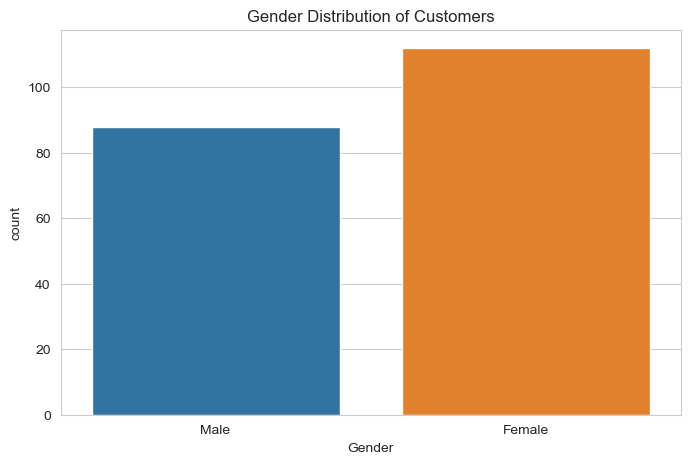

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', data=df, hue='Gender')
plt.title('Gender Distribution of Customers')
plt.show()

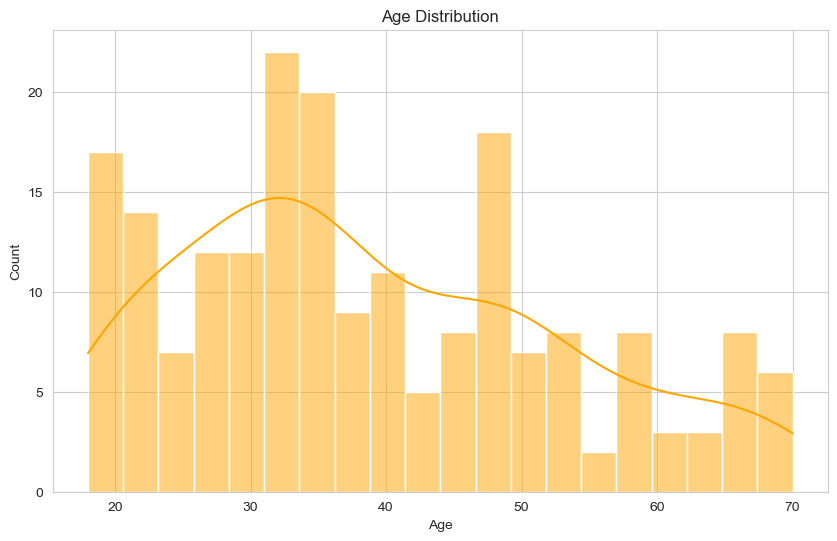

In [45]:

plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True, bins=20, color='orange')
plt.title('Age Distribution')
plt.show()

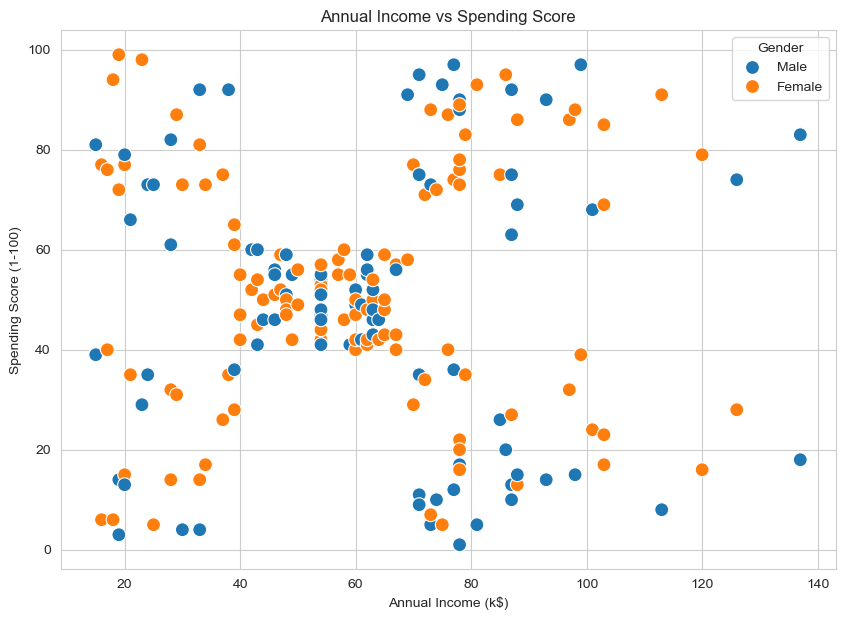

In [25]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Gender', data=df, s=100)
plt.title('Annual Income vs Spending Score')
plt.show()

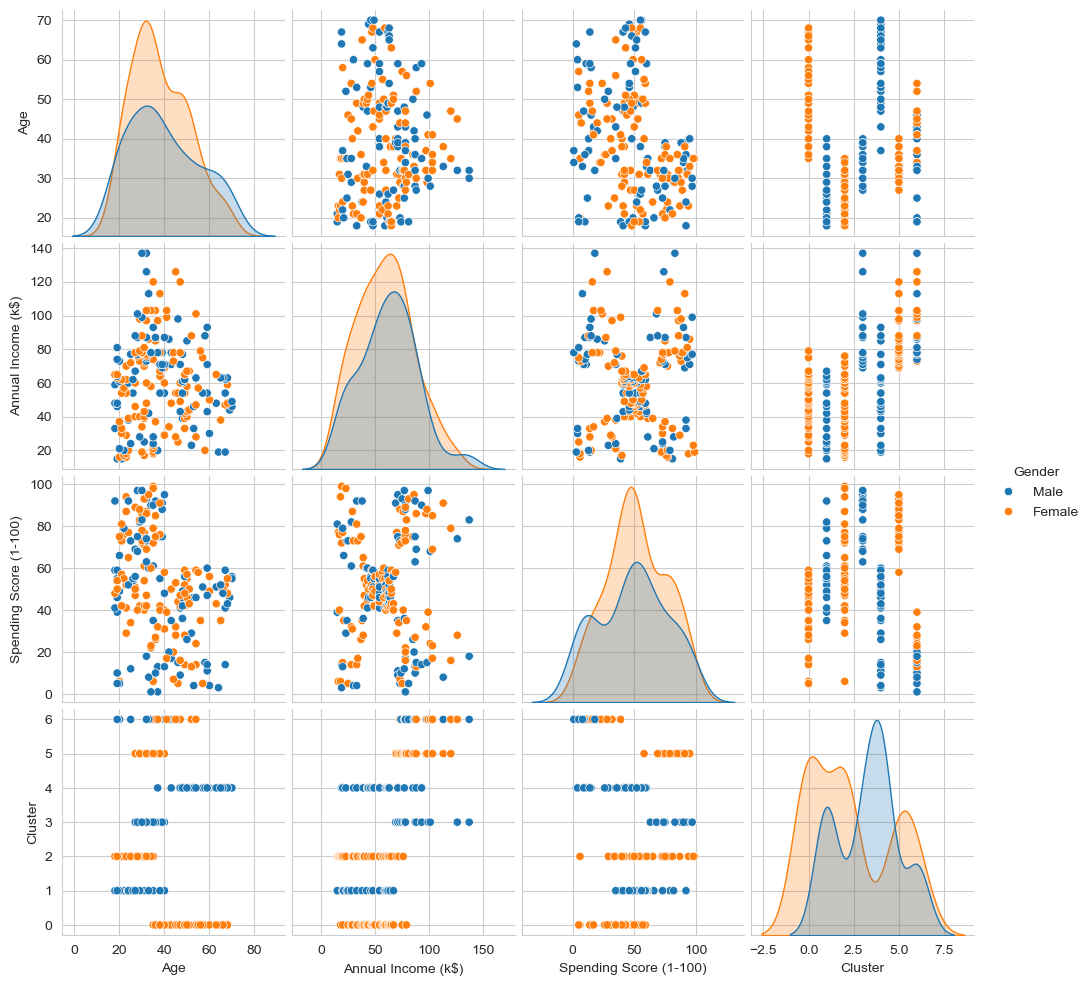

In [26]:
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender')
plt.show()

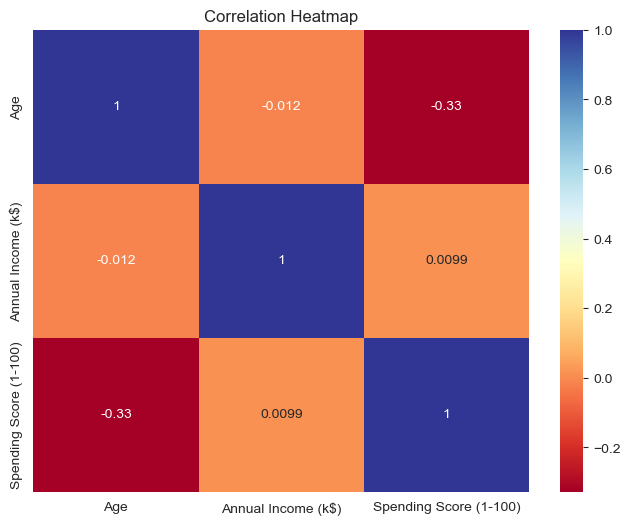

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), 
            annot=True, cmap='RdYlBu')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
X = df.drop(['CustomerID'], axis=1)

In [29]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

Text(0, 0.5, 'Inertia')

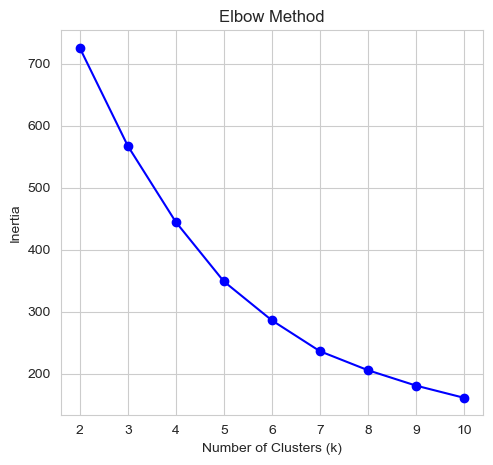

In [32]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')


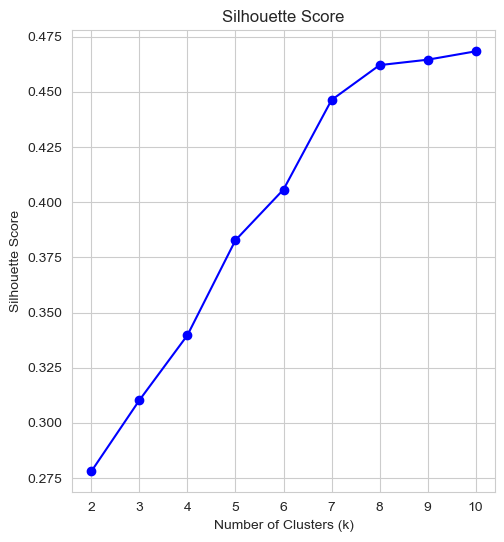

In [33]:
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, 'bo-')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [34]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster Distribution:")
print(df['Cluster'].value_counts())

Cluster Distribution:
Cluster
4    40
0    37
1    33
2    26
3    24
6    22
5    18
Name: count, dtype: int64


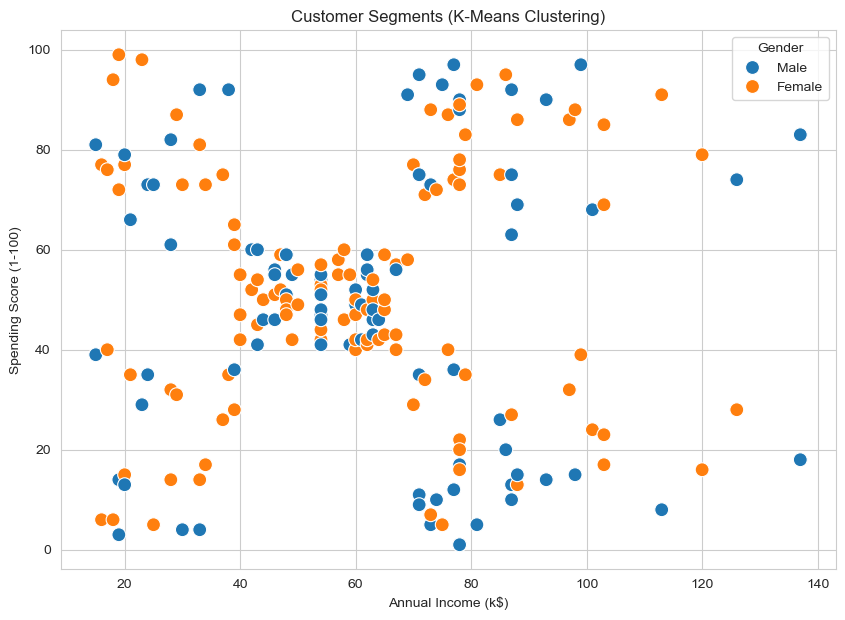

In [37]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Gender', data=df, s=100)
plt.title('Customer Segments (K-Means Clustering)')
plt.show()

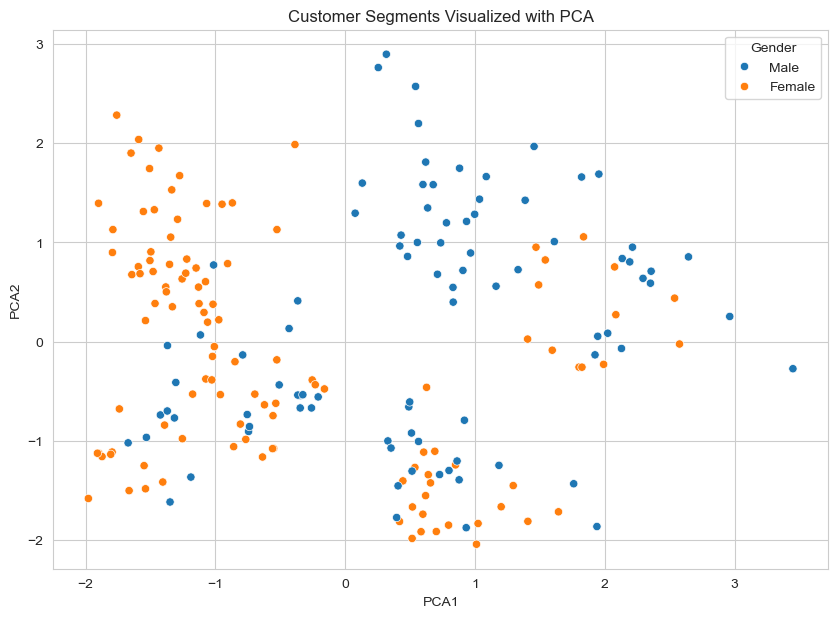

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Gender', data=df, )
plt.title('Customer Segments Visualized with PCA')
plt.show()